In [24]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load experiment results

In [25]:
cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load data
data_path = os.path.join('..', cfg['paths']['mgf_data_path'])
data = torch.load(data_path, weights_only=False)


In [26]:
model = SimpleTransformer(**cfg['architecture'])
model_path = os.path.join('..', cfg['paths']['save_dir'], 'model_mgf.pth')

if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    # Handle both old format (direct state dict) and new format (checkpoint dict)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        # New format with loss history
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded model from {model_path}")
        if 'loss_history' in checkpoint:
            loss_history = checkpoint['loss_history']
            print(f"Loss history available: {len(loss_history['train_losses'])} epochs")
        if 'config' in checkpoint:
            print(f"Model trained with config: {checkpoint['config']}")
    else:
        # Old format (direct state dict)
        model.load_state_dict(checkpoint)
        print(f"Loaded model (old format) from {model_path}")
    
    model.to(device)
    model.eval()
else:
    print(f"Model not found at {model_path}")
    print("Run: python ../scripts/train.py")

Loaded model from ../experiments/model_mgf.pth
Model trained with config: {'physics': {'theta': 0.15, 'mu': 0.0, 'sigma': 0.2, 'dt': 0.1, 'marginal_variance': 0.2}, 'theta_sampling': {'distribution': 'lognormal', 'mean': 0.0, 'sigma': 0.4}, 'structure': {'num_trajectories': 1000, 'sequence_length': 100}, 'target': {'order': 6}, 'training': {'train_split': 0.8, 'batch_size': 64}, 'paths': {'mgf_data_path': 'data/ou_mgf.pt', 'save_dir': 'experiments', 'mgf_model_name': 'model_mgf.pth'}, 'architecture': {'d_input': 1, 'd_model': 10, 'n_head': 2, 'n_layers': 2, 'max_len': 5000, 'dim_feedforward': 9, 'd_output': 6}, 'hyperparameters': {'batch_size': 64, 'learning_rate': 0.001, 'epochs': 2000}, 'system': {'device': 'cpu'}}


In [27]:
model

SimpleTransformer(
  (input_projection): Linear(in_features=1, out_features=10, bias=True)
  (pos_encoder): PositionalEncoding()
  (layers): ModuleList(
    (0-1): 2 x AttentionBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_features=10, bias=True)
      )
      (norm1): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=10, out_features=9, bias=True)
        (1): ReLU()
        (2): Linear(in_features=9, out_features=10, bias=True)
      )
      (norm2): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
    )
  )
  (output_projection): Linear(in_features=10, out_features=6, bias=True)
)

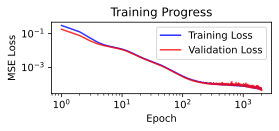

Final training loss: 0.000048
Final validation loss: 0.000044


In [28]:
# Load and plot loss history if available
loss_history_path = os.path.join('..', cfg['paths']['save_dir'], 'loss_history.pt')

if os.path.exists(loss_history_path):
    loss_data = torch.load(loss_history_path, weights_only=False)
    
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(1, 1, figsize=(4, 2))
    
    epochs = range(1, len(loss_data['train_losses']) + 1)
    ax.plot(epochs, loss_data['train_losses'], 'b-', label='Training Loss', alpha=0.8)
    
    if loss_data['val_losses']:
        ax.loglog(epochs, loss_data['val_losses'], 'r-', label='Validation Loss', alpha=0.8)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Training Progress')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Final training loss: {loss_data['train_losses'][-1]:.6f}")
    if loss_data['val_losses']:
        print(f"Final validation loss: {loss_data['val_losses'][-1]:.6f}")
else:
    print("No loss history found. Train the model to generate loss tracking data.")

In [29]:
# Generate test dataset with fixed marginal variance and varying theta
import numpy as np

# Test dataset parameters
num_test_trajectories = 600  # Number of trajectories per theta value
num_theta_values = 30  # Number of different theta values to test
sequence_length = 30
mu = 0.0
dt = 0.1
fixed_marginal_variance = np.sqrt(0.2)  # Fixed across all trajectories

# Create equally spaced theta values in a reasonable range
theta_min = 0.1
theta_max = 5.0
theta_grid = np.linspace(theta_min, theta_max, num_theta_values)

# Repeat each theta value for num_test_trajectories times
theta_values = np.repeat(theta_grid, num_test_trajectories)
theta_tensor = torch.from_numpy(theta_values).float()

# Total number of trajectories
total_trajectories = num_theta_values * num_test_trajectories
print(f"Generating {total_trajectories} trajectories ({num_test_trajectories} per theta value)")
print(f"Theta range: {theta_min:.2f} to {theta_max:.2f} with {num_theta_values} values")

# Create D_tensor to maintain fixed marginal variance: D = marginal_variance * θ
D_tensor = fixed_marginal_variance * theta_tensor

# Generate trajectories
test_trajectories = simulate_ou_process(total_trajectories, sequence_length, theta_tensor, mu, D_tensor, dt)

# Generate corresponding targets (same structure as training data)
order = cfg['target']['order']
test_targets = torch.zeros(total_trajectories, sequence_length, order)

# Compute theoretical targets
theta_expanded = theta_tensor.unsqueeze(1)  # (total_trajectories, 1)
D_expanded = D_tensor.unsqueeze(1)  # (total_trajectories, 1)
exp_theta_dt = torch.exp(-theta_expanded * dt)

# First entry: conditional mean μ + (X_t - μ) * exp(-θ * dt) 
test_targets[:, :, 0] = mu + (test_trajectories[:, :, 0] - mu) * exp_theta_dt

# Second entry: conditional variance (D/θ) * (1 - exp(-2θ * dt))
conditional_variance = (D_expanded / theta_expanded) * (1 - torch.exp(-2 * theta_expanded * dt))
test_targets[:, :, 1] = conditional_variance.expand_as(test_targets[:, :, 1])

Generating 18000 trajectories (600 per theta value)
Theta range: 0.10 to 5.00 with 30 values


In [13]:
model_preds = model(test_trajectories)[0][:,-1,0].detach().cpu().numpy()
truth = test_targets[:, -1, 0].numpy()

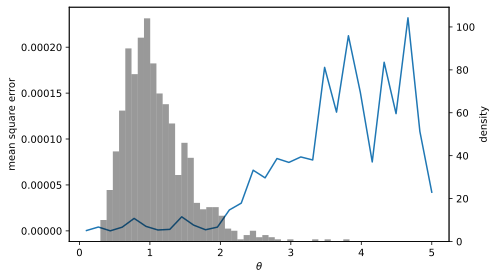

In [23]:
fig,ax = plt.subplots(figsize=(7,4))

errs = model_preds - truth
abs_errs = np.abs(errs**2)

# Match theta values to the actual number of predictions we got
# Slice theta_tensor to match the length of predictions
n_preds = len(model_preds)
theta_for_preds = theta_tensor[:n_preds]
theta_numpy = theta_for_preds.cpu().numpy()
unique_thetas = np.unique(theta_numpy)



# Calculate mean and std for each theta group
mean_errors = []
std_errors = []
for theta_val in unique_thetas:
    mask = theta_numpy == theta_val
    theta_errors = errs[mask]
    mean_errors.append(np.mean(theta_errors)**2)
    std_errors.append(np.var(theta_errors))

mean_errors = np.array(mean_errors)
std_errors = np.array(std_errors)

# Plot grouped errors with error bars
axt = ax.twinx()
axt.hist(data['theta_values'].numpy(),40,color="k",alpha=0.4)
axt.set_ylabel("density")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("mean square error")
#ax.set_xlim([0,np.max(unique_thetas)])
#ax.set_ylim([0,0.1])

#ax.plot(unique_thetas, std_errors)
ax.plot(unique_thetas, mean_errors)
# ax.errorbar(unique_thetas, mean_errors, yerr=std_errors, 
#            fmt='o-', capsize=3, capthick=1, alpha=0.8, 
#            color='red', markersize=4)
#ax.semilogy()
#ax.vlines(1/dt, ymin=1e-8, ymax=1e-1, color='gray', linestyle='--', label=r'$\theta=1$')

plt.tight_layout()

In [38]:
1/dt

10.0

In [ ]:
model